<a href="https://colab.research.google.com/github/EdK2003/group12/blob/main/Project_Group_12_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical imaging with MedGemma

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tueimage/8dm60-multimodal-ai/blob/main/project/medical-imaging-starter.ipynb)

This starter workbook demoes three ways to work with a **medical generative vision-language model** and the Indiana University Chest X-ray dataset:

1. Generate a report for one chest X-ray and compare it with the reference report.
2. Extract frozen image features and explore their structure with t-SNE.
3. Adapt the language decoder with QLoRA and compare training and validation loss.


Each section introduces a question, implements one small experiment, and ends with some discussion questions. The sections are starting points for research questions, not complete experiments, nor an exhaustive set of research questions you can address as part of the project work. You can, but you are  not limited to use a MedGemme or a generative VLM in your project work, this is just one example of a model that is appropriate.

> **Important:** The first run downloads the complete dataset (about 14.2 GB) and the model weights. Make sure the runtime has at least 35 GB of free local disk space.


## Table of contents

1. [Overview and prerequisites](#1-overview-and-prerequisites)
2. [Settings](#2-settings)
3. [Download and prepare the dataset](#3-download-and-prepare-the-dataset)
4. [Load MedGemma](#4-load-medgemma)
5. [Generate and inspect a report](#5-generate-and-inspect-a-report)
6. [Explore image features](#6-explore-image-features)
7. [Fine-tune with QLoRA](#7-fine-tune-with-qlora)
8. [From demonstration to research project](#8-from-demonstration-to-research-project)


## 1. Overview and prerequisites

Use one of the following two compute options:

- **TU/e HPC:** For this course, we provide students access to one of our high performance computing (HPC) servers, which is equipped with NVIDIA 2080ti GPUs. More information will be given during the first BZ.
- **Google Colab:** choose **Runtime → Change runtime type → GPU**. Colab storage is temporary, so downloaded data is lost when the runtime is reset.

Run the installation cell once. **If it installs or changes packages, restart the Jupyter kernel or Colab runtime before continuing so the new packages take effect.** Then run the remaining cells section by section. Note that Section 7 performs GPU training and can take longer time to complete.

Before loading the model, visit the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it) while signed in and accept the Health AI Developer Foundations terms. Also create a read token in your [Hugging Face settings](https://huggingface.co/settings/tokens). In Colab, you may store it as an `HF_TOKEN` secret and grant the notebook access; otherwise, a later cell opens the appropriate login interface.

The workbook uses the following libraries:

- **PyTorch** runs model inference and adapter training on the GPU.
- **torchvision** supplies image transforms used by the model processor.
- **Transformers** provides MedGemma, its processor, generation, and quantized loading.
- **Hugging Face Hub** authenticates access to the gated model and caches its files.
- **Accelerate** places the model on the GPU, without requiring CPU memory load first.
- **bitsandbytes** stores the frozen base model in 4-bit form so it fits in 11 GB.
- **PEFT** adds the small trainable LoRA adapters; together with a 4-bit base this is called QLoRA.
- **KaggleHub** downloads and caches the X-Ray dataset.
- **pandas** prepares report and projection metadata.
- **NumPy**, **Pillow**, **Matplotlib**, and **scikit-learn** support data handling, image loading, plots, PCA, and t-SNE.

The course environment installs the complete pinned stack. Colab keeps its preinstalled PyTorch, CUDA, and scientific Python stack and installs only the model-specific packages. This avoids replacing packages maintained as one compatible Colab runtime image. The environment cell reports the resulting versions for reproducibility.


In [1]:
from importlib.util import find_spec
import subprocess
import sys

print(f"Python {sys.version.split()[0]}")

# A direct dependencies are pinned to a specific versionso so all students
# work with the same model and preprocessing behavior.
model_requirements = [
    "transformers==4.57.6",
    "huggingface_hub==0.36.0",
    "accelerate==1.6.0",
    "bitsandbytes==0.49.2",
    "peft==0.15.2",
    "kagglehub==1.0.2",
    "num2words==0.5.14",
    "ipywidgets==8.1.8",
    "sentencepiece==0.2.1",
]

IN_COLAB = (
    find_spec("google") is not None
    and find_spec("google.colab") is not None
)

if IN_COLAB:
    # Keep Colab's matched PyTorch/CUDA and scientific Python packages.
    requirements = model_requirements
    print("Colab detected: keeping its preinstalled compute stack.")
else:
    requirements = [
        "torch==2.13.0",
        "torchvision==0.28.0",
        "pandas==3.0.3",
        "Pillow==12.3.0",
        "matplotlib==3.11.1",
        "scikit-learn==1.9.0",
        "numpy==2.5.1",
        *model_requirements,
    ]

# Install into the environment used by this notebook kernel.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--disable-pip-version-check",
        *requirements,
    ]
)


Python 3.13.15
Colab detected: keeping its preinstalled compute stack.


0

In [2]:
%matplotlib inline

# Standard-library utilities handle paths, disk space, and reporting.
from importlib.metadata import version
from pathlib import Path
from shutil import disk_usage
import sys
import textwrap

# Scientific Python libraries handle data, images, plots, and projections.
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Transformers supplies the multimodal processor, model, and quantization config.
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "This workbook requires a CUDA-enabled PyTorch environment. "
        "Select the course GPU kernel, or choose a GPU runtime in Colab."
    )

# Print the library versions (for debugging purposes)
print(f"Python: {sys.version.split()[0]}")
for distribution in (
    "torch", "torchvision", "transformers", "huggingface_hub",
    "accelerate",
    "bitsandbytes", "peft", "kagglehub", "pandas", "Pillow",
    "matplotlib", "scikit-learn", "numpy", "num2words",
    "ipywidgets",
):
    print(f"{distribution}: {version(distribution)}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Python: 3.13.15
torch: 2.11.0+cu130
torchvision: 0.26.0+cu130
transformers: 4.57.6
huggingface_hub: 0.36.0
accelerate: 1.6.0
bitsandbytes: 0.49.2
peft: 0.15.2
kagglehub: 1.0.2
pandas: 2.2.3
Pillow: 11.3.0
matplotlib: 3.10.0
scikit-learn: 1.6.1
numpy: 2.1.3
num2words: 0.5.14
ipywidgets: 8.1.8
GPU: Tesla T4


## 2. Settings

The settings below are the main controls you may want to change:

- `PROMPT` is used for baseline generation, QLoRA training, validation, and the final comparison. It requests the short report format used in this exercise.
- `EXAMPLE_INDEX` selects one study ID from the reproducibly sorted table; counting starts at zero.
- `MAX_NEW_TOKENS` limits generated report length. Tokens are pieces of words, not an exact word count.
- `COMPUTE_DTYPE` selects the arithmetic precision used around the 4-bit weights. FP32 is slower but works consistently on the course RTX 2080 Ti and Colab GPUs; keeping it fixed also makes results easier to compare.
- `STUDIES_PER_CLASS` requests an equal number of studies for each report-derived feature label.
- `MAX_TRAINING_TOKENS` bounds the complete image-prompt-report sequence during training to control memory use.
- The default fine-tuning settings use 100 training and 20 validation studies for a relatively quick demonstration. Each block averages ten optimizer steps, and validation runs after every two blocks.

For a fuller experiment, set `TRAINING_STUDIES = 1000`, `VALIDATION_STUDIES = 100`, and `VALIDATE_EVERY_N_BLOCKS = 10`. Changing an early setting requires rerunning the cells that depend on it.


In [3]:
# General model and reproducibility settings.
SEED = 0
MODEL_ID = "google/medgemma-4b-it"
SYSTEM_PROMPT = "You are an expert radiologist."
PROMPT = (
    "Write a concise radiology report for this frontal chest X-ray. "
    "Use Findings and Impression sections. Describe only findings "
    "supported by the image and state uncertainty when necessary."
)

MAX_NEW_TOKENS = 160
COMPUTE_DTYPE = torch.float32

# Report generation settings.
EXAMPLE_INDEX = 3

# Representation-exploration settings.
STUDIES_PER_CLASS = 100

# Quick QLoRA defaults; the preceding Markdown gives fuller settings.
TRAINING_STUDIES = 100
VALIDATION_STUDIES = 20
STUDIES_PER_BLOCK = 10
VALIDATE_EVERY_N_BLOCKS = 2
MAX_TRAINING_TOKENS = 640
FINETUNE_LEARNING_RATE = 2e-4

# Few-shot experiments: three fixed demonstration selections per shot count.
SHOT_COUNTS = (0, 1, 2, 4)
DEMONSTRATION_SEEDS = (11, 23, 37)


## 3. Download and prepare the dataset

The [Indiana University Chest X-ray dataset](https://openi.nlm.nih.gov/faq) contains chest X-rays paired with radiology reports. The KaggleHub call downloads the complete [Kaggle mirror](https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university) into its local cache. In Colab, the cache is stored on the runtime's fast local disk and disappears when the runtime is reset.

> One report can describe several images from the same study, often frontal and lateral views. This workbook keeps only one frontal image but compares it with the study-level report. A reference statement may therefore describe information that is not visible in the supplied image.

In [4]:
# Check if there is sufficient storage space for the dataset, model weights, and temporary files.
free_disk_gb = disk_usage(Path.home()).free / 2**30
print(f"Available disk space: {free_disk_gb:.1f} GB")
if free_disk_gb < 35:
    raise RuntimeError(
        "At least 35 GB of free disk space is required."
    )

# KaggleHub reuses its local cache after the first 14.2 GB download.
DATASET_ID = "raddar/chest-xrays-indiana-university"
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))
print(f"Dataset directory: {dataset_root}")

Available disk space: 69.7 GB
Using Colab cache for faster access to the 'chest-xrays-indiana-university' dataset.
Dataset directory: /kaggle/input/chest-xrays-indiana-university


In [5]:
reports = pd.read_csv(dataset_root / "indiana_reports.csv")
projections = pd.read_csv(dataset_root / "indiana_projections.csv")

# Replace missing report sections with empty text, strip leading and trailing whitespaces.
for column in ("findings", "impression"):
    reports[column] = reports[column].fillna("").str.strip()

# Select one frontal image for each study.
frontals = (
    projections[projections["projection"].str.lower().eq("frontal")]
    .sort_values(["uid", "filename"])
    .drop_duplicates("uid")
)

# Merge reports and frontal scans based on uid.
studies = reports.merge(frontals, on="uid")

# Remove cases with empty reports, re-index the dataset (remove old index).
studies = studies[
    studies["findings"].ne("") | studies["impression"].ne("")
].sort_values("uid").reset_index(drop=True)

# Append the image path to the dataset
image_dir = dataset_root / "images" / "images_normalized"
studies["image_path"] = studies["filename"].map(image_dir.joinpath)

print(f"Prepared {len(studies):,} frontal-image studies.")

Prepared 3,666 frontal-image studies.


In [6]:
from sklearn.model_selection import train_test_split

train_ids, remaining_ids = train_test_split(
    studies["uid"].to_numpy(),
    train_size=0.60,
    random_state=SEED,
    shuffle=True,
)

val_ids, test_ids = train_test_split(
    remaining_ids,
    train_size=0.25,
    random_state=SEED,
    shuffle=True,
)

train_studies = studies[studies["uid"].isin(train_ids)].reset_index(drop=True)
val_studies = studies[studies["uid"].isin(val_ids)].reset_index(drop=True)
test_studies = studies[studies["uid"].isin(test_ids)].reset_index(drop=True)

assert len(train_studies) + len(val_studies) + len(test_studies) == len(studies)
assert set(train_studies["uid"]).isdisjoint(val_studies["uid"])
assert set(train_studies["uid"]).isdisjoint(test_studies["uid"])
assert set(val_studies["uid"]).isdisjoint(test_studies["uid"])

print(
    f"Train: {len(train_studies)}, "
    f"validation: {len(val_studies)}, "
    f"test: {len(test_studies)}"
)

Train: 2199, validation: 366, test: 1101


In [7]:
def format_reference(row):
    """Combine findings and impression sections of a report."""
    sections = []
    if row["findings"]:
        sections.append(f"Findings\n{row['findings']}")
    if row["impression"]:
        sections.append(f"Impression\n{row['impression']}")
    return "\n\n".join(sections)


def load_xray(path):
    """Load a scan as RGB image (RGB format is expected by MedGemma)."""
    with Image.open(path) as opened_image:
        return opened_image.convert("RGB")


# Use a training study for this illustrative example.
if not 0 <= EXAMPLE_INDEX < len(train_studies):
    raise IndexError(
        f"EXAMPLE_INDEX must be between 0 and {len(train_studies) - 1}."
    )

study = train_studies.iloc[EXAMPLE_INDEX]
image = load_xray(study["image_path"])
reference_report = format_reference(study)

print(f"Selected training study {study['uid']} ({study['filename']}).")


Selected training study 12 (12_IM-0133-1001.dcm.png).


## 4. Load MedGemma

[MedGemma 4B Instruct](https://huggingface.co/google/medgemma-4b-it) is a generative medical vision-language model based on Gemma 3. Its vision encoder was pretrained on several kinds of medical imagery, including chest X-rays. See Sellergren et al. (2025), [*MedGemma Technical Report*](https://arxiv.org/abs/2507.05201).

Gemma 3 converts each image to a fixed 896×896 encoder input. We retain that native resolution and for speed and simplicity we disable optional **pan-and-scan**, which adds additional local crops to the input.

To reduce GPU memory use, we load the model with its weights quantized to 4 bit NF4 format. The published MedGemma examples use BF16 computation, but the RTX 2080 Ti used in the course does not support BF16 natively, and the GPU provided by Colab may vary. On the RTX 2080 Ti, FP16 can become numerically unstable and cause the model to generate empty responses. We therefore use FP32 computation together with the quantized weights in both environments. This is slower but a lot more reliable. For reference, the numerical formats mentioned above are briefly summarized below.

| Format | Explanation |
|---|---|
| **NF4** | A 4 bit quantization format designed for normally distributed model weights that substantially reduces GPU memory use. |
| **FP16** | A 16 bit floating point format that is fast and memory efficient on many GPUs but can be numerically unstable. |
| **BF16** | A 16 bit floating point format with a wider numerical range than FP16, but it requires compatible GPU hardware for efficient native computation. |
| **FP32** | A 32 bit floating point format that uses more memory and computation but generally provides the greatest numerical stability. |

### Authorize the model download

MedGemma is a gated model, meaning that you must sign in to Hugging Face and accept the model’s terms before you can download its files. First accept its terms on the [model page](https://huggingface.co/google/medgemma-4b-it), using the same Hugging Face account that owns your read token. The next cell reuses an available token or opens the appropriate login interface for Jupyter or Colab.

In [9]:
from huggingface_hub import HfApi, hf_hub_download, login

# Reuse an existing token, including Colab's HF_TOKEN secret.
# An interactive prompt appears only when no token is available.
login(new_session=False)

# Verify the account and its access to the gated MedGemma repository.
hf_account = HfApi().whoami()["name"]
hf_hub_download(MODEL_ID, "config.json")

print(f"Authenticated with Hugging Face as {hf_account}.")


config.json: 0.00B [00:00, ?B/s]

Authenticated with Hugging Face as BoontjeNicky.


In [10]:
# Load the processor that prepares both text and images for MedGemma.
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
# Disable creation of additional local image crops during preprocessing.
processor.image_processor.do_pan_and_scan = False

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    dtype=COMPUTE_DTYPE,
    attn_implementation="eager", # Use the standard but slower implementation for broad GPU compatibility.
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

print(f"MedGemma image size: {processor.image_processor.size}")
print(f"GPU memory after loading: {torch.cuda.memory_allocated() / 2**30:.1f} GB")


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma image size: {'height': 896, 'width': 896}
GPU memory after loading: 4.3 GB


## 5. Generate and inspect a report

MedGemma follows Gemma 3's chat format. A system message establishes the role, and the user message contains the actual image plus the editable prompt. The processor inserts visual tokens, resizes the image, and tokenizes the conversation. The generation is deterministic (`do_sample=False`) so prompt changes are easier to compare.


In [11]:
def make_messages(current_image, prompt, assistant_text=None):
    """Build one image-and-text conversation for MedGemma."""
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": current_image},
            ],
        },
    ]
    # During training, append the reference report as the target response.
    if assistant_text is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": assistant_text}],
            }
        )
    return messages


def encode_messages(messages, add_generation_prompt, **tokenizer_kwargs):
    """Apply the model's chat template and create PyTorch tensors."""
    return processor.apply_chat_template(
        messages,
        add_generation_prompt=add_generation_prompt,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        **tokenizer_kwargs,
    )


def move_batch_to_gpu(batch, device):
    """Move a processor batch to the GPU."""
    batch = {name: value.to(device) for name, value in batch.items()}
    batch["pixel_values"] = batch["pixel_values"].to(COMPUTE_DTYPE)
    return batch


def generate_report(current_model, current_image, prompt, max_new_tokens):
    """Generate a report and decode only tokens created by the model.

    ``generate`` returns the input prompt followed by the new response, so
    the prompt length is recorded and removed before decoding.
    """
    batch = encode_messages(
        make_messages(current_image, prompt),
        add_generation_prompt=True,
    )
    batch = move_batch_to_gpu(batch, current_model.device)
    input_length = batch["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = current_model.generate(
            **batch,
            do_sample=False,
            use_cache=True,
            max_new_tokens=max_new_tokens,
        )

    new_token_ids = output_ids[0, input_length:]
    return processor.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()


In [12]:
# Generate a deterministic baseline before any adapter training.
generated_report = generate_report(
    model, image, PROMPT, MAX_NEW_TOKENS
)
print(f"Prompt: {PROMPT}")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: Write a concise radiology report for this frontal chest X-ray. Use Findings and Impression sections. Describe only findings supported by the image and state uncertainty when necessary.


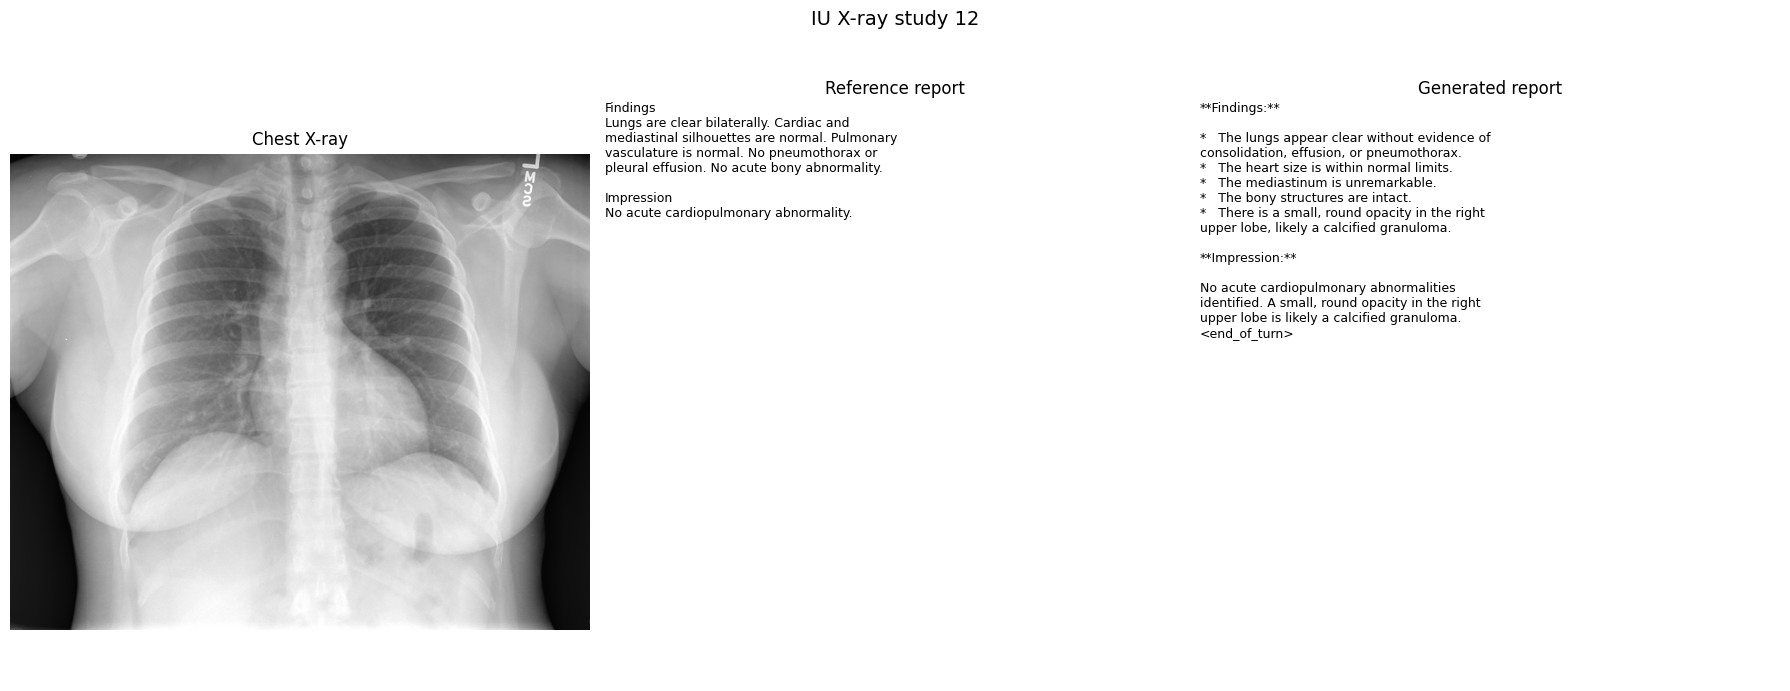

In [13]:
def wrap_report(report, width=48):
    """Wrap report lines without discarding section breaks."""
    return "\n".join(
        textwrap.fill(line, width=width) if line else ""
        for line in report.splitlines()
    )


def add_report_panel(axis, title, report, width=48):
    """Render report text in a Matplotlib axis."""
    axis.text(
        0, 1, wrap_report(report, width),
        va="top", ha="left", fontsize=9, transform=axis.transAxes,
    )
    axis.set_title(title)
    axis.axis("off")


# Place the image, reference, and generated report side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(image)
axes[0].set_title("Chest X-ray")
axes[0].axis("off")
add_report_panel(axes[1], "Reference report", reference_report)
add_report_panel(axes[2], "Generated report", generated_report)
fig.suptitle(f"IU X-ray study {study['uid']}", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

In [ ]:
# Zero-shot uses no demonstrations.
prompt_configs = {"zero_shot": []}

# For each seed, select four training studies in a fixed order.
# The first 1, 2, or 4 form that seed's shot configurations.
for seed in DEMONSTRATION_SEEDS:
    selected = train_studies.sample(
        n=4,
        random_state=seed,
    )

    for shots in (1, 2, 4):
        name = f"{shots}_shot_seed_{seed}"
        prompt_configs[name] = selected.iloc[:shots].to_dict("records")

for name, demonstrations in prompt_configs.items():
    print(name, [row["uid"] for row in demonstrations])

zero_shot []
1_shot_seed_11 [2283]
2_shot_seed_11 [2283, 3164]
4_shot_seed_11 [2283, 3164, 49, 3908]
1_shot_seed_23 [2208]
2_shot_seed_23 [2208, 2055]
4_shot_seed_23 [2208, 2055, 2851, 3797]
1_shot_seed_37 [1993]
2_shot_seed_37 [1993, 2220]
4_shot_seed_37 [1993, 2220, 2545, 2589]


In [ ]:
def make_fewshot_messages(target_image, demonstrations):
    """Build a MedGemma conversation with image–report examples."""
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        }
    ]

    for demo in demonstrations:
        demo_image = load_xray(demo["image_path"])
        demo_report = format_reference(demo)

        # Add the demonstration image and its reference report.
        messages.extend(
            make_messages(
                demo_image,
                PROMPT,
                assistant_text=demo_report,
            )[1:]  # Skip the repeated system message.
        )

    # Add the study for which MedGemma must generate a report.
    messages.extend(make_messages(target_image, PROMPT)[1:])
    return messages

In [ ]:
def generate_fewshot_report(current_model, row, demonstrations):
    """Generate one report using the selected demonstrations."""
    target_image = load_xray(row["image_path"])
    messages = make_fewshot_messages(target_image, demonstrations)

    batch = encode_messages(
        messages,
        add_generation_prompt=True,
    )
    batch = move_batch_to_gpu(batch, current_model.device)
    input_length = batch["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = current_model.generate(
            **batch,
            do_sample=False,
            use_cache=True,
            max_new_tokens=MAX_NEW_TOKENS,
        )

    new_token_ids = output_ids[0, input_length:]
    return processor.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()

In [ ]:
# Use the same fixed validation studies for every configuration.
N_PROMPT_VALIDATION = 30
prompt_val_studies = val_studies.sample(
    n=N_PROMPT_VALIDATION,
    random_state=SEED,
).sort_values("uid")

validation_rows = []

for config_name, demonstrations in prompt_configs.items():
    for _, row in prompt_val_studies.iterrows():
        validation_rows.append({
            "uid": row["uid"],
            "config": config_name,
            "reference": format_reference(row),
            "generated": generate_fewshot_report(
                model, row, demonstrations
            ),
        })

    print(f"Finished {config_name}")

validation_reports = pd.DataFrame(validation_rows)

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
validation_reports.to_csv(
    results_dir / "validation_reports.csv",
    index=False,
)

print(f"Saved {len(validation_reports)} validation reports.")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Finished zero_shot
Finished 1_shot_seed_11


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.67 GiB is free. Including non-PyTorch memory, this process has 11.89 GiB memory in use. Of the allocated memory 7.59 GiB is allocated by PyTorch, and 4.16 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
annotation_path = results_dir / "validation_annotations.csv"

if not annotation_path.exists():
    annotation_sheet = validation_reports.copy()
    annotation_sheet["supported"] = pd.NA
    annotation_sheet["omitted"] = pd.NA
    annotation_sheet["unsupported"] = pd.NA
    annotation_sheet.to_csv(annotation_path, index=False)

print(f"Complete the three count columns in: {annotation_path}")

In [ ]:
annotated_val = pd.read_csv(
    annotation_path,
    dtype={"uid": str},
)

# Check that every generated report has exactly one annotation.
expected = {
    (str(row["uid"]), row["config"])
    for _, row in validation_reports.iterrows()
}
observed = list(zip(
    annotated_val["uid"],
    annotated_val["config"],
))

if len(observed) != len(expected) or set(observed) != expected:
    raise ValueError(
        "Annotations must contain exactly one row per validation report."
    )

for column in ("supported", "omitted", "unsupported"):
    values = pd.to_numeric(annotated_val[column], errors="raise")
    if values.isna().any() or (values < 0).any() or (values % 1 != 0).any():
        raise ValueError(
            f"Complete '{column}' with nonnegative whole numbers."
        )
    annotated_val[column] = values.astype(int)

# Finding-level F1: supported findings count as correct;
# omissions and unsupported findings count as errors.
denominator = (
    2 * annotated_val["supported"]
    + annotated_val["omitted"]
    + annotated_val["unsupported"]
)
annotated_val["clinical_f1"] = (
    2 * annotated_val["supported"] / denominator.where(denominator != 0, 1)
)
annotated_val.loc[denominator == 0, "clinical_f1"] = 1.0

mean_scores = annotated_val.groupby("config")["clinical_f1"].mean()

selected_names = ["zero_shot"]
for shots in (1, 2, 4):
    candidates = [
        name for name in prompt_configs
        if name.startswith(f"{shots}_shot_")
    ]
    best = sorted(
        candidates,
        key=lambda name: (-mean_scores[name], name),
    )[0]
    selected_names.append(best)

selected_configs = {
    name: prompt_configs[name]
    for name in selected_names
}

print("Mean validation scores:")
print(mean_scores.sort_index())
print("Selected configurations:", selected_names)

In [ ]:
# Choose the test studies once; QLoRA will use these same studies later.
N_TEST = 100
test_eval_studies = test_studies.sample(
    n=N_TEST,
    random_state=SEED,
).sort_values("uid")

prompt_test_rows = []

for config_name, demonstrations in selected_configs.items():
    for _, row in test_eval_studies.iterrows():
        prompt_test_rows.append({
            "uid": row["uid"],
            "method": "prompting",
            "config": config_name,
            "reference": format_reference(row),
            "generated": generate_fewshot_report(
                model, row, demonstrations
            ),
        })

    print(f"Finished test reports for {config_name}")

prompt_test_reports = pd.DataFrame(prompt_test_rows)
prompt_test_reports.to_csv(
    results_dir / "prompt_test_reports.csv",
    index=False,
)

print(f"Saved {len(prompt_test_reports)} prompting test reports.")

## 6. Fine-tune with QLoRA

To fine-tune MedGemma, we first prepare a training set of image–report pairs. Each example contains one frontal chest X-ray, the fixed reporting prompt, and its reference report as the target response. The processor converts these elements into one multimodal sequence. During teacher-forced training, the model predicts each report token from the image, prompt, and preceding report tokens. Loss is calculated only for the report because the image and prompt provide context rather than desired output (masking their labels prevents the objective from rewarding reproduction of the instruction and image-placeholder tokens).

A disjoint set of studies is reserved for validation and excluded from optimizer updates. It measures report-prediction loss on examples not used to fit the adapter, although repeated monitoring means it is not an untouched final test set.

During training, the model minimizes next-token prediction loss over the reference reports. **LoRA** is a form of **parameter-efficient fine-tuning (PEFT)**: rather than updating the full language decoder, it learns low-rank updates to selected query and value projection matrices while keeping the original MedGemma parameters frozen. This substantially reduces the number of trainable parameters and the memory required for optimization. See Hu et al. (2021), [*LoRA: Low-Rank Adaptation of Large Language Models*](https://arxiv.org/abs/2106.09685).

MedGemma's frozen weights are kept in 4-bit NF4 form while the adapters are trained with FP32 computation. This combination is **QLoRA**; see Dettmers et al. (2023), [*QLoRA: Efficient Finetuning of Quantized LLMs*](https://arxiv.org/abs/2305.14314). FP32 avoids unstable FP16 outputs and behaves consistently across the supported GPUs, but makes this demonstration slower.

> **Runtime note:** The default setup trains on 100 studies and evaluates performance on 20 validation studies at five points during training. The Settings section discusses configuration values for a larger experiment.

We use the term **training block** for a fixed number of consecutive training examples between progress reports and validation runs. A block is not an epoch: each study is used once, and completing all blocks corresponds to one pass through the selected training subset.


In [ ]:
# Draw the fixed QLoRA sample sizes from the correct splits.
if TRAINING_STUDIES > len(train_studies):
    raise ValueError("TRAINING_STUDIES exceeds the training split.")
if VALIDATION_STUDIES > len(val_studies):
    raise ValueError("VALIDATION_STUDIES exceeds the validation split.")
if TRAINING_STUDIES % STUDIES_PER_BLOCK != 0:
    raise ValueError(
        "TRAINING_STUDIES must be divisible by STUDIES_PER_BLOCK."
    )

training_blocks = TRAINING_STUDIES // STUDIES_PER_BLOCK

finetune_studies = train_studies.sample(
    n=TRAINING_STUDIES,
    random_state=SEED,
).reset_index(drop=True)

validation_studies = val_studies.sample(
    n=VALIDATION_STUDIES,
    random_state=SEED,
).reset_index(drop=True)

# Cell 33 uses this image to check the training-label boundary.
training_study = finetune_studies.iloc[0]
training_image = load_xray(training_study["image_path"])

print(f"QLoRA training studies: {len(finetune_studies)}")
print(f"QLoRA loss-validation studies: {len(validation_studies)}")
print(f"Training blocks: {training_blocks}")

### Add trainable adapters

The adapters are added only to the language decoder's query and value projections. The vision encoder therefore remains frozen. Rank `r=8` controls the small inner dimension of each adapter. Gradient checkpointing saves memory by recomputing some activations during backpropagation.


In [ ]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

torch.manual_seed(SEED)

# Freeze and prepare the 4-bit base model for LoRA training. Gradient
# checkpointing reduces memory use by recomputing activations during backward.
# Non-reentrant checkpointing needs to be set when only the LoRA adapters, rather
# than the model inputs or frozen base weights, require gradients.
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

# Select only the query and value projections in the language decoder.
# Full module paths exclude similarly named layers in the vision encoder.
text_lora_targets = [
    name
    for name, _ in model.named_modules()
    if "language_model" in name
    and name.endswith(("q_proj", "v_proj"))
]

# Fail early if the model's module structure differs from what we expect.
if not text_lora_targets:
    raise RuntimeError("Could not find language-decoder query/value projections.")

# Configure low-rank adapters for the selected language-decoder projections.
lora_config = LoraConfig(
    r=8,                           # Rank of each low-dimensional update.
    lora_alpha=8,                  # Update scaling; alpha/r gives a scale of 1.
    lora_dropout=0.05,             # Apply dropout on the adapter input.
    target_modules=text_lora_targets,
    bias="none",                   # Keep the original bias parameters frozen.
)

# Insert the LoRA adapters and return a PEFT-wrapped model.
model = get_peft_model(model, lora_config)

# Disable generation-oriented key/value caching during checkpointed training.
model.config.text_config.use_cache = False

# Enable training behavior, including LoRA dropout.
model.train()

# Report how many parameters are trainable after adding the adapters.
model.print_trainable_parameters()


### Build assistant-only training labels

For each training example, the processor creates two model inputs:

- `input_ids`: the sequence of integer token identifiers representing the system message, image placeholders, user prompt, and assistant report. Each identifier refers to a token in the model's vocabulary.
- `pixel_values`: the processed image data associated with those placeholders.

Both are passed to the model in the same training step. The model learns to predict each report token using the image, the prompt, and the correct preceding report tokens. Providing the correct (and not the predicted) preceding tokens during training is called **teacher forcing**.

The `labels` tensor serves a different purpose: it specifies the target token at each position and therefore which positions contribute to cross-entropy loss. We copy `input_ids` into `labels`, then replace the labels for the image and prompt portion with `-100`, PyTorch's ignore value. This masks the **loss**, not the **input**. The context tokens still influence the model through attention, but no error is assigned for predicting the fixed system message, prompt, or image placeholders. The resulting objective trains the conditional behavior we want—predicting the assistant report given the image and prompt—rather than spending much of the learning signal on reproducing the input template.

With pan-and-scan disabled, every example contributes the same fixed number of image tokens. We therefore determine the prompt boundary once and verify that it is an exact prefix of one complete training conversation.

The training sequence is capped by `MAX_TRAINING_TOKENS` to keep memory predictable.


In [ ]:
# Measure the prompt once so its tokens can be excluded from the loss.
prompt_batch = encode_messages(
    make_messages(training_image, PROMPT),
    add_generation_prompt=True,
)
prompt_token_count = prompt_batch["input_ids"].shape[1]


def make_training_batch(row, current_model):
    """Encode one study and mask every token before the target report."""
    row_image = load_xray(row["image_path"])
    batch = encode_messages(
        make_messages(
            row_image,
            PROMPT,
            assistant_text=format_reference(row),
        ),
        add_generation_prompt=False,
        truncation=True,
        max_length=MAX_TRAINING_TOKENS,
    )
    if prompt_token_count >= batch["input_ids"].shape[1]:
        raise RuntimeError("The reference report produced no target tokens.")

    labels = batch["input_ids"].clone()
    labels[:, :prompt_token_count] = -100
    batch["labels"] = labels
    return move_batch_to_gpu(batch, current_model.device)


# Verify the masking boundary once, rather than trusting a token count blindly.
example_batch = make_training_batch(finetune_studies.iloc[0], model)
if not torch.equal(
    example_batch["input_ids"][0, :prompt_token_count].cpu(),
    prompt_batch["input_ids"][0],
):
    raise RuntimeError("The chat template is not prefix-preserving.")
target_token_count = int(example_batch["labels"].ne(-100).sum())
print(f"First reference target: {target_token_count} tokens.")
del prompt_batch, example_batch


### Train and validate the adapters

The next cell performs one pass through the selected training studies and periodically measures validation loss. The optimizer receives only parameters with `requires_grad=True`, so it updates the LoRA adapters while the quantized MedGemma weights remain frozen. To fit within GPU memory, training uses a batch size of one: for each study, the loop clears old gradients, computes the assistant-only report loss, backpropagates, clips the gradients, and performs one optimizer step. Training loss is then averaged over each block for reporting.

At the configured intervals, the model switches to evaluation mode and computes the same report-prediction loss across the validation studies without gradients or parameter updates. It then returns to training mode for the next block. Comparing the two loss curves helps reveal optimization progress and possible overfitting, but lower loss alone does not establish that generated reports are clinically correct.


In [ ]:
trainable_parameters = [
    parameter for parameter in model.parameters() if parameter.requires_grad
]
optimizer = torch.optim.AdamW(
    trainable_parameters, lr=FINETUNE_LEARNING_RATE
)
training_losses = []
validation_blocks = []
validation_losses = []

# Each block reports the mean of several batch-size-one optimizer steps.
for block_index in range(training_blocks):
    start = block_index * STUDIES_PER_BLOCK
    stop = start + STUDIES_PER_BLOCK
    block_studies = finetune_studies.iloc[start:stop]
    block_loss = 0.0

    # Batch size is one; each study produces one optimizer update.
    for _, training_study in block_studies.iterrows():
        optimizer.zero_grad(set_to_none=True)
        batch = make_training_batch(training_study, model)
        loss = model(**batch).loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()
        block_loss += loss.detach().item()
        # Drop references promptly to stay within the 11 GB GPU budget.
        del batch, loss

    mean_training_loss = block_loss / len(block_studies)
    training_losses.append(mean_training_loss)
    completed_block = block_index + 1
    should_validate = (
        completed_block % VALIDATE_EVERY_N_BLOCKS == 0
        or completed_block == training_blocks
    )

    if should_validate:
        model.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for _, validation_row in validation_studies.iterrows():
                validation_batch = make_training_batch(validation_row, model)
                validation_loss = model(**validation_batch).loss
                validation_total += validation_loss.item()
                # Validation also runs close to the GPU memory limit.
                del validation_batch, validation_loss

        mean_validation_loss = validation_total / len(validation_studies)
        validation_blocks.append(completed_block)
        validation_losses.append(mean_validation_loss)
        model.train()
        print(
            f"Block {completed_block:03d}/{training_blocks}: "
            f"train = {mean_training_loss:.4f}, "
            f"validation = {mean_validation_loss:.4f}"
        )
    else:
        print(
            f"Block {completed_block:03d}/{training_blocks}: "
            f"train = {mean_training_loss:.4f}"
        )

In [ ]:
# Training loss is averaged per block; validation loss uses the full split.
plt.figure(figsize=(7, 4))
blocks = range(1, training_blocks + 1)
plt.plot(
    blocks, training_losses,
    label=f"Training ({STUDIES_PER_BLOCK} studies per block)",
)
plt.plot(
    validation_blocks, validation_losses, marker="o",
    label=f"Validation ({VALIDATION_STUDIES} studies)",
)
plt.xlabel("Training block")
plt.ylabel("Report-prediction loss")
plt.title("LoRA training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Evaluate QLoRA on the held-out test studies

The QLoRA model was trained on studies drawn from the training split.
Validation loss was monitored using studies from the validation split.

We now generate QLoRA reports for the same fixed test studies used by
zero-shot and the selected few-shot configurations. This provides a
held-out comparison across methods. The test studies were not used to
train QLoRA or select demonstrations.

In [ ]:
# Return to generation mode after QLoRA training.
model.gradient_checkpointing_disable()
model.config.text_config.use_cache = True
model.eval()

qlora_test_rows = []

for _, row in test_eval_studies.iterrows():
    qlora_test_rows.append({
        "uid": row["uid"],
        "method": "QLoRA",
        "config": "fixed_starter",
        "reference": format_reference(row),
        "generated": generate_report(
            model,
            load_xray(row["image_path"]),
            PROMPT,
            MAX_NEW_TOKENS,
        ),
    })

qlora_test_reports = pd.DataFrame(qlora_test_rows)
qlora_test_reports.to_csv(
    results_dir / "qlora_test_reports.csv",
    index=False,
)

print(f"Saved {len(qlora_test_reports)} QLoRA test reports.")


In [ ]:
# Combine all held-out reports for assessment.
all_test_reports = pd.concat(
    [prompt_test_reports, qlora_test_reports],
    ignore_index=True,
)

assert set(prompt_test_reports["uid"]) == set(qlora_test_reports["uid"])

test_annotation_path = results_dir / "test_annotations.csv"

if not test_annotation_path.exists():
    test_annotation_sheet = all_test_reports.copy()
    test_annotation_sheet["supported"] = pd.NA
    test_annotation_sheet["omitted"] = pd.NA
    test_annotation_sheet["unsupported"] = pd.NA
    test_annotation_sheet.to_csv(test_annotation_path, index=False)

print(f"Complete the three count columns in: {test_annotation_path}")
print(f"Reports to assess: {len(all_test_reports)}")

In [ ]:
annotated_test = pd.read_csv(
    test_annotation_path,
    dtype={"uid": str},
)

expected = {
    (str(row["uid"]), row["method"], row["config"])
    for _, row in all_test_reports.iterrows()
}
observed = list(zip(
    annotated_test["uid"],
    annotated_test["method"],
    annotated_test["config"],
))

if len(observed) != len(expected) or set(observed) != expected:
    raise ValueError(
        "Annotations must contain exactly one row per test report."
    )

for column in ("supported", "omitted", "unsupported"):
    values = pd.to_numeric(annotated_test[column], errors="raise")
    if values.isna().any() or (values < 0).any() or (values % 1 != 0).any():
        raise ValueError(
            f"Complete '{column}' with nonnegative whole numbers."
        )
    annotated_test[column] = values.astype(int)

denominator = (
    2 * annotated_test["supported"]
    + annotated_test["omitted"]
    + annotated_test["unsupported"]
)
annotated_test["clinical_f1"] = (
    2 * annotated_test["supported"]
    / denominator.where(denominator != 0, 1)
)
annotated_test.loc[denominator == 0, "clinical_f1"] = 1.0

summary = annotated_test.groupby(
    ["method", "config"]
).agg(
    studies=("uid", "nunique"),
    mean_clinical_f1=("clinical_f1", "mean"),
    supported=("supported", "sum"),
    omitted=("omitted", "sum"),
    unsupported=("unsupported", "sum"),
)

display(summary)

##7. Deep dive QLoRA on a larger training set
The QLoRA training in section 6 uses the starter notebook's small demonstration settings (100 studies). This section explores whether a larger more thorough QLoRA run improves clinical fidelity compared to that small demo,  using the same train/validation/test split already defined above. Settings are kept seperate so this does not change the results already produced above.

In [14]:
PROJECT_TRAINING_STUDIES = 300
PROJECT_VALIDATION_STUDIES = 50
PROJECT_STUDIES_PER_BLOCK = 20
PROJECT_VALIDATE_EVERY_N_BLOCKS = 3

project_training_blocks = PROJECT_TRAINING_STUDIES // PROJECT_STUDIES_PER_BLOCK

project_finetune_studies = train_studies.sample(
    n=PROJECT_TRAINING_STUDIES, random_state=SEED
).reset_index(drop=True)
project_validation_studies = val_studies.sample(
    n=PROJECT_VALIDATION_STUDIES, random_state=SEED
).reset_index(drop=True)

print(f"Project training studies: {len(project_finetune_studies)}")
print(f"Project validation studies: {len(project_validation_studies)}")
print(f"Project training blocks: {project_training_blocks}")

Project training studies: 300
Project validation studies: 50
Project training blocks: 15


In [15]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    dtype=COMPUTE_DTYPE,
    attn_implementation="eager",
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

print(f"GPU memory after reloading fresh model: {torch.cuda.memory_allocated() / 2**30:.1f} GB")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

GPU memory after reloading fresh model: 6.0 GB


In [16]:
# Cel A: baseline vastleggen
project_training_study = project_finetune_studies.iloc[0]
project_validation_study = project_validation_studies.iloc[0]
project_training_image = load_xray(project_training_study["image_path"])
project_validation_image = load_xray(project_validation_study["image_path"])
project_training_reference = format_reference(project_training_study)
project_validation_reference = format_reference(project_validation_study)

project_training_before = generate_report(
    model, project_training_image, PROMPT, MAX_NEW_TOKENS
)
project_validation_before = generate_report(
    model, project_validation_image, PROMPT, MAX_NEW_TOKENS
)
print("Baseline (pretrained) reports recorded for the project example studies.")

Baseline (pretrained) reports recorded for the project example studies.


In [17]:
# Cel B: LoRA-adapters toevoegen
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

torch.manual_seed(SEED)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

text_lora_targets = [
    name
    for name, _ in model.named_modules()
    if "language_model" in name
    and name.endswith(("q_proj", "v_proj"))
]

if not text_lora_targets:
    raise RuntimeError("Could not find language-decoder query/value projections.")

lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=text_lora_targets,
    bias="none",
)

model = get_peft_model(model, lora_config)
model.config.text_config.use_cache = False
model.train()
model.print_trainable_parameters()

trainable params: 2,228,224 || all params: 4,302,307,696 || trainable%: 0.0518


In [18]:
# Cel C: assistant-only labels bouwen
prompt_batch = encode_messages(
    make_messages(project_training_image, PROMPT),
    add_generation_prompt=True,
)
prompt_token_count = prompt_batch["input_ids"].shape[1]


def make_training_batch(row, current_model):
    """Encode one study and mask every token before the target report."""
    row_image = load_xray(row["image_path"])
    batch = encode_messages(
        make_messages(
            row_image,
            PROMPT,
            assistant_text=format_reference(row),
        ),
        add_generation_prompt=False,
        truncation=True,
        max_length=MAX_TRAINING_TOKENS,
    )
    if prompt_token_count >= batch["input_ids"].shape[1]:
        raise RuntimeError("The reference report produced no target tokens.")

    labels = batch["input_ids"].clone()
    labels[:, :prompt_token_count] = -100
    batch["labels"] = labels
    return move_batch_to_gpu(batch, current_model.device)


example_batch = make_training_batch(project_finetune_studies.iloc[0], model)
if not torch.equal(
    example_batch["input_ids"][0, :prompt_token_count].cpu(),
    prompt_batch["input_ids"][0],
):
    raise RuntimeError("The chat template is not prefix-preserving.")
target_token_count = int(example_batch["labels"].ne(-100).sum())
print(f"First reference target: {target_token_count} tokens.")
del prompt_batch, example_batch

First reference target: 68 tokens.


Block 001/15: train = 2.2851
Block 002/15: train = 1.5795
Block 003/15: train = 1.6925, validation = 1.5420
Block 004/15: train = 1.6383
Block 005/15: train = 1.4539
Block 006/15: train = 1.3996, validation = 1.4194
Block 007/15: train = 1.3057
Block 008/15: train = 1.1978
Block 009/15: train = 1.3812, validation = 1.3940
Block 010/15: train = 1.4362
Block 011/15: train = 1.0366
Block 012/15: train = 1.3267, validation = 1.3692
Block 013/15: train = 1.4637
Block 014/15: train = 1.3958
Block 015/15: train = 1.3273, validation = 1.3170


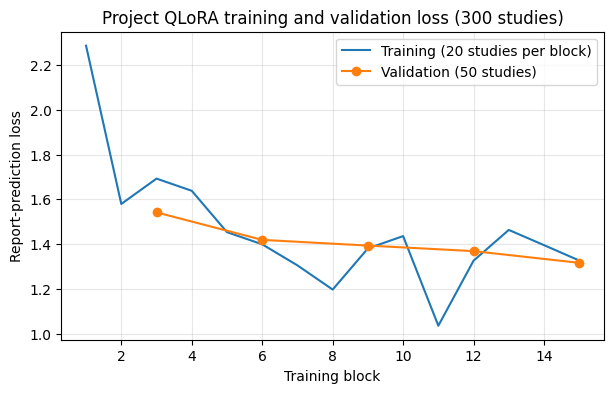

In [19]:
# Cel D: trainen en valideren
trainable_parameters = [
    parameter for parameter in model.parameters() if parameter.requires_grad
]
optimizer = torch.optim.AdamW(
    trainable_parameters, lr=FINETUNE_LEARNING_RATE
)
project_training_losses = []
project_validation_blocks = []
project_validation_losses = []

for block_index in range(project_training_blocks):
    start = block_index * PROJECT_STUDIES_PER_BLOCK
    stop = start + PROJECT_STUDIES_PER_BLOCK
    block_studies = project_finetune_studies.iloc[start:stop]
    block_loss = 0.0

    for _, training_row in block_studies.iterrows():
        optimizer.zero_grad(set_to_none=True)
        batch = make_training_batch(training_row, model)
        loss = model(**batch).loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()
        block_loss += loss.detach().item()
        del batch, loss

    mean_training_loss = block_loss / len(block_studies)
    project_training_losses.append(mean_training_loss)
    completed_block = block_index + 1
    should_validate = (
        completed_block % PROJECT_VALIDATE_EVERY_N_BLOCKS == 0
        or completed_block == project_training_blocks
    )

    if should_validate:
        model.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for _, validation_row in project_validation_studies.iterrows():
                validation_batch = make_training_batch(validation_row, model)
                validation_loss = model(**validation_batch).loss
                validation_total += validation_loss.item()
                del validation_batch, validation_loss

        mean_validation_loss = validation_total / len(project_validation_studies)
        project_validation_blocks.append(completed_block)
        project_validation_losses.append(mean_validation_loss)
        model.train()
        print(
            f"Block {completed_block:03d}/{project_training_blocks}: "
            f"train = {mean_training_loss:.4f}, "
            f"validation = {mean_validation_loss:.4f}"
        )
    else:
        print(
            f"Block {completed_block:03d}/{project_training_blocks}: "
            f"train = {mean_training_loss:.4f}"
        )

plt.figure(figsize=(7, 4))
blocks = range(1, project_training_blocks + 1)
plt.plot(
    blocks, project_training_losses,
    label=f"Training ({PROJECT_STUDIES_PER_BLOCK} studies per block)",
)
plt.plot(
    project_validation_blocks, project_validation_losses, marker="o",
    label=f"Validation ({PROJECT_VALIDATION_STUDIES} studies)",
)
plt.xlabel("Training block")
plt.ylabel("Report-prediction loss")
plt.title("Project QLoRA training and validation loss (300 studies)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#torch.save(model.state_dict(), 'model')

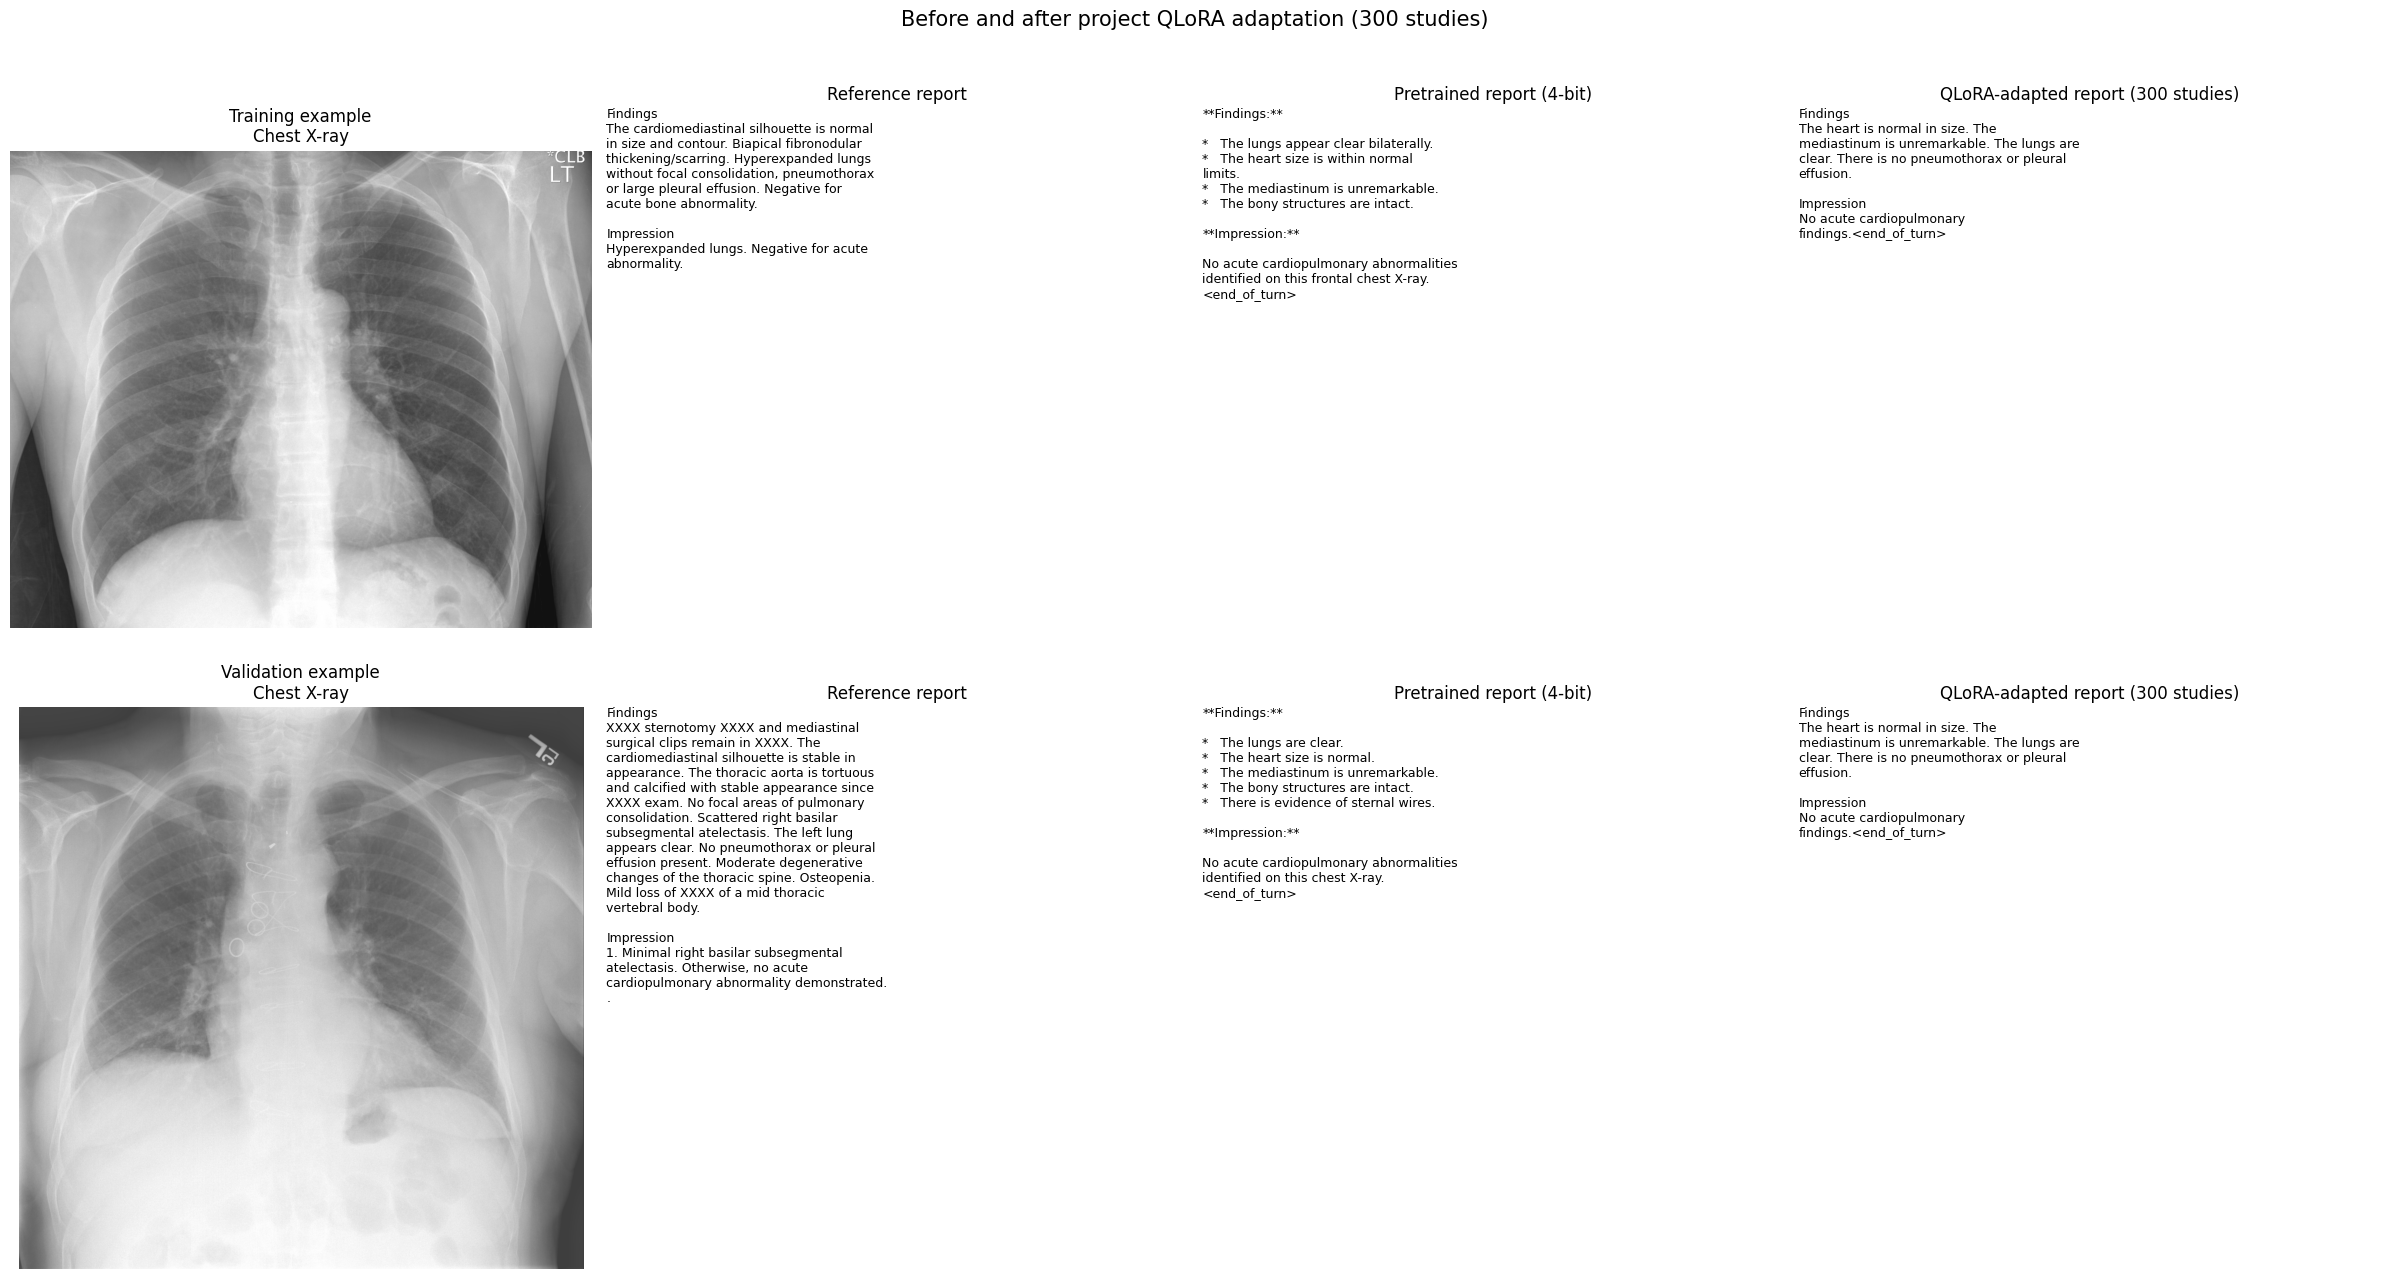

In [20]:
# Cel E: voor/na-vergelijking
model.gradient_checkpointing_disable()
model.config.text_config.use_cache = True
model.eval()

project_training_after = generate_report(
    model, project_training_image, PROMPT, MAX_NEW_TOKENS
)
project_validation_after = generate_report(
    model, project_validation_image, PROMPT, MAX_NEW_TOKENS
)

comparison_rows = [
    (
        "Training example", project_training_image, project_training_reference,
        project_training_before, project_training_after,
    ),
    (
        "Validation example", project_validation_image, project_validation_reference,
        project_validation_before, project_validation_after,
    ),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 13))
for row_index, (label, xray, reference, before, after) in enumerate(comparison_rows):
    axes[row_index, 0].imshow(xray)
    axes[row_index, 0].set_title(f"{label}\nChest X-ray")
    axes[row_index, 0].axis("off")
    for column, (title, report) in enumerate(
        [
            ("Reference report", reference),
            ("Pretrained report (4-bit)", before),
            ("QLoRA-adapted report (300 studies)", after),
        ],
        start=1,
    ):
        add_report_panel(axes[row_index, column], title, report, width=42)

fig.suptitle("Before and after project QLoRA adaptation (300 studies)", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [21]:
# Recreate the same test sample as cell 27, without running the heavy
# few-shot generation loop that normally comes with it. Deterministic
# thanks to random_state=SEED, so this matches exactly what the rest of
# the team's few-shot evaluation also uses.
N_TEST = 100
test_eval_studies = test_studies.sample(
    n=N_TEST,
    random_state=SEED,
).sort_values("uid")

print(f"Test evaluation studies: {len(test_eval_studies)}")

Test evaluation studies: 100


In [23]:
#Cel F: Return to generation mode after the larger project QLoRA training.
model.gradient_checkpointing_disable()
model.config.text_config.use_cache = True
model.eval()

project_qlora_test_rows = []

for _, row in test_eval_studies.iterrows():
    project_qlora_test_rows.append({
        "uid": row["uid"],
        "method": "QLoRA",
        "config": "project_300_studies",   # <-- eigen label, niet "fixed_starter"
        "reference": format_reference(row),
        "generated": generate_report(
            model,
            load_xray(row["image_path"]),
            PROMPT,
            MAX_NEW_TOKENS,
        ),
    })

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

project_qlora_test_reports = pd.DataFrame(project_qlora_test_rows)
project_qlora_test_reports.to_csv(
    results_dir / "project_qlora_test_reports.csv",
    index=False,
)

print(f"Saved {len(project_qlora_test_reports)} project QLoRA test reports.")

Saved 100 project QLoRA test reports.


In [24]:
# Cel G: Combine project QLoRA reports with the existing test reports for assessment,
# using a SEPARATE annotation file so nothing already filled in by a
# teammate gets overwritten.
project_test_reports = pd.concat(
    [project_qlora_test_reports],
    ignore_index=True,
)

project_test_annotation_path = results_dir / "project_qlora_test_annotations.csv"

if not project_test_annotation_path.exists():
    project_annotation_sheet = project_test_reports.copy()
    project_annotation_sheet["supported"] = pd.NA
    project_annotation_sheet["omitted"] = pd.NA
    project_annotation_sheet["unsupported"] = pd.NA
    project_annotation_sheet.to_csv(project_test_annotation_path, index=False)

print(f"Complete the three count columns in: {project_test_annotation_path}")
print(f"Reports to assess: {len(project_test_reports)}")

Complete the three count columns in: results/project_qlora_test_annotations.csv
Reports to assess: 100


In [25]:
# Cel H: bereken clinical_f1 en vergelijken
project_annotated_test = pd.read_csv(
    project_test_annotation_path,
    dtype={"uid": str},
)

for column in ("supported", "omitted", "unsupported"):
    values = pd.to_numeric(project_annotated_test[column], errors="raise")
    if values.isna().any() or (values < 0).any() or (values % 1 != 0).any():
        raise ValueError(f"Complete '{column}' with nonnegative whole numbers.")
    project_annotated_test[column] = values.astype(int)

denominator = (
    2 * project_annotated_test["supported"]
    + project_annotated_test["omitted"]
    + project_annotated_test["unsupported"]
)
project_annotated_test["clinical_f1"] = (
    2 * project_annotated_test["supported"]
    / denominator.where(denominator != 0, 1)
)
project_annotated_test.loc[denominator == 0, "clinical_f1"] = 1.0

project_summary = project_annotated_test.groupby(
    ["method", "config"]
).agg(
    studies=("uid", "nunique"),
    mean_clinical_f1=("clinical_f1", "mean"),
    supported=("supported", "sum"),
    omitted=("omitted", "sum"),
    unsupported=("unsupported", "sum"),
)

display(project_summary)

# Combine with the existing summary table for a direct side-by-side comparison.
combined_summary = pd.concat([summary, project_summary])
display(combined_summary)

ValueError: Complete 'supported' with nonnegative whole numbers.